# MIT 805 Big Data Semester Project
## Part 1 - Data Collection and Exploratory Data Analysis

### Dataset
New York City Taxi & Limousine Commission (NYC TLC) **High-Volume For-Hire Vehicle (HVFHV)** Trip Records — app-dispatched for-hire trips reported by licensed high-volume bases.

### Domain
Transport / Urban Mobility

### Dataset selection
The project requires a large publicly available dataset and explicit reporting of raw, working and processing sizes. HVFHV is well suited because the TLC publishes monthly Parquet files with rich trip, temporal, spatial and financial fields such as request/pickup/drop-off timestamps, trip miles, base passenger fare, driver pay, tips and shared-ride indicators.

The official files are measured at run time and a project raw collection is selected to meet the required 25-40 GB range.

### Data Source
NYC TLC — official page: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page  
Direct files: `https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_YYYY-MM.parquet`

### Notebook structure
1. Setup and reproducible output folders
2. Dataset scale discovery (raw / working / processing sizes)
3. Load one representative month for Part 1 EDA
4. Schema, derived fields and data-quality assessment
5. Cleaning (raw preserved, transparent plausibility filters)
6. Exploratory Data Analysis (temporal, spatial, company and wait-time patterns)
7. Saved outputs and final summary


## 1. Setup and reproducible output folders


In [98]:
import os
import requests
try:
  import polars as pl
except ModuleNotFoundError:
  !pip install polars
  import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# Two-decimal display in Polars tables
pl.Config.set_float_precision(2)

# Point PROJECT_ROOT at your cloned repo root in Colab, e.g. "/content/project",
# so figures/ and output/ land straight inside the repo for the reproducibility mark.
PROJECT_ROOT = "."
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
OUT_DIR = os.path.join(PROJECT_ROOT, "output")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def save_fig(name, dpi=200):
    """Call right before plt.show() so the saved PNG is not blank."""
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=dpi, bbox_inches="tight")

base_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/"
print("Setup complete.")


Setup complete.


## 2. Dataset scale discovery

We query the official TLC server directly using HTTP HEAD requests to measure the available HVFHV Parquet files and then define the three project dataset levels:

* **Raw project dataset** = a continuous collection of original TLC HVFHV files whose combined compressed size is within **25-40 GB**.
* **Working dataset** = a subset of the raw project dataset prepared for the project, with size **≥ 12 GB**.
* **Processing dataset** = a subset of the working dataset designated for distributed PySpark analysis in Part 2, with size **≥ 3 GB**.

The code first checks whether the complete available HVFHV corpus itself falls in the required raw range. If it does not, it selects a continuous recent window of original TLC files that reaches at least 25 GB without exceeding 40 GB. This avoids making a fixed size claim before the official files have been measured.


### 2.1 Generate candidate file names


In [99]:
from datetime import datetime

# HVFHV data begins in February 2019.
current_year = datetime.now().year

candidate_files = []
for year in range(2019, current_year + 1):
    start_month = 2 if year == 2019 else 1
    for month in range(start_month, 13):
        filename = f"fhvhv_tripdata_{year}-{month:02d}.parquet"
        candidate_files.append({
            "year": year,
            "month": month,
            "filename": filename,
            "url": base_url + filename
        })

print("Candidate HVFHV files to check:", len(candidate_files))


Candidate HVFHV files to check: 95


### 2.2 Measure each file with an HTTP HEAD request


In [100]:
def get_file_metadata(record):
    try:
        response = requests.head(record["url"], allow_redirects=True, timeout=30)
        if response.status_code == 200:
            size_bytes = int(response.headers.get("Content-Length", 0))
            return {**record, "exists": True,
                    "size_bytes": size_bytes,
                    "size_MB": size_bytes / (1024 ** 2),
                    "size_GB": size_bytes / (1024 ** 3)}
    except requests.RequestException:
        pass
    return {**record, "exists": False, "size_bytes": 0, "size_MB": 0, "size_GB": 0}


In [101]:
metadata_list = []
for i, record in enumerate(candidate_files):
    meta = get_file_metadata(record)
    metadata_list.append(meta)
    status = f"{meta['size_GB']:.3f} GB" if meta["exists"] else "not available"
    print(f"{i + 1:>2}/{len(candidate_files)}  {record['filename']}  {status}")


 1/95  fhvhv_tripdata_2019-02.parquet  0.478 GB
 2/95  fhvhv_tripdata_2019-03.parquet  0.569 GB
 3/95  fhvhv_tripdata_2019-04.parquet  0.521 GB
 4/95  fhvhv_tripdata_2019-05.parquet  0.532 GB
 5/95  fhvhv_tripdata_2019-06.parquet  0.499 GB
 6/95  fhvhv_tripdata_2019-07.parquet  0.481 GB
 7/95  fhvhv_tripdata_2019-08.parquet  0.467 GB
 8/95  fhvhv_tripdata_2019-09.parquet  0.481 GB
 9/95  fhvhv_tripdata_2019-10.parquet  0.512 GB
10/95  fhvhv_tripdata_2019-11.parquet  0.522 GB
11/95  fhvhv_tripdata_2019-12.parquet  0.537 GB
12/95  fhvhv_tripdata_2020-01.parquet  0.495 GB
13/95  fhvhv_tripdata_2020-02.parquet  0.520 GB
14/95  fhvhv_tripdata_2020-03.parquet  0.323 GB
15/95  fhvhv_tripdata_2020-04.parquet  0.107 GB
16/95  fhvhv_tripdata_2020-05.parquet  0.150 GB
17/95  fhvhv_tripdata_2020-06.parquet  0.184 GB
18/95  fhvhv_tripdata_2020-07.parquet  0.242 GB
19/95  fhvhv_tripdata_2020-08.parquet  0.271 GB
20/95  fhvhv_tripdata_2020-09.parquet  0.293 GB
21/95  fhvhv_tripdata_2020-10.parquet  0

### 2.3 Build the available-file table


In [102]:
available = (pl.DataFrame(metadata_list)
             .filter(pl.col("exists"))
             .sort(["year", "month"]))

full_corpus_gb = available["size_bytes"].sum() / (1024 ** 3)

print("Available files:", available.height)
print(f"Full public HVFHV corpus: {full_corpus_gb:.2f} GB")
print("Coverage:", available[0, "filename"], "to", available[-1, "filename"])


Available files: 89
Full public HVFHV corpus: 37.58 GB
Coverage: fhvhv_tripdata_2019-02.parquet to fhvhv_tripdata_2026-06.parquet


### 2.4 Define the RAW project dataset (25-40 GB)

The analysis does not assume that the complete public HVFHV corpus is automatically within the assignment's 25-40 GB raw-data range.

1. First, it calculates the size of the complete currently available HVFHV corpus.
2. If that complete corpus is between 25 and 40 GB, it is used as the raw project dataset.
3. Otherwise, the notebook selects the **most recent continuous set of original TLC monthly files** until the combined size reaches at least 25 GB, while ensuring it does not exceed 40 GB.

The selected raw dataset therefore consists of unchanged original TLC files and meets the project scale requirement.


In [103]:
full_corpus_size_gb = available["size_bytes"].sum() / (1024 ** 3)
print(f"Complete available HVFHV corpus: {available.height} files, {full_corpus_size_gb:.2f} GB")

if 25 <= full_corpus_size_gb <= 40:
    raw_dataset = available
    raw_selection_method = "Complete available HVFHV corpus"
else:
    # Build a continuous recent window from original TLC files.
    recent_first = available.sort(["year", "month"], descending=True)
    selected = []
    total_bytes = 0

    for row in recent_first.iter_rows(named=True):
        next_total_gb = (total_bytes + row["size_bytes"]) / (1024 ** 3)

        if total_bytes / (1024 ** 3) >= 25:
            break

        if next_total_gb > 40:
            raise ValueError(
                "Could not build a 25-40 GB raw collection with the current monthly file sizes. "
                "Inspect the available-file table and adjust the window deliberately."
            )

        selected.append(row)
        total_bytes += row["size_bytes"]

    raw_dataset = pl.DataFrame(selected).sort(["year", "month"])
    raw_selection_method = "Most recent continuous window of original TLC HVFHV files"

raw_size_gb = raw_dataset["size_bytes"].sum() / (1024 ** 3)

print("\nRAW PROJECT DATASET")
print("Selection method:", raw_selection_method)
print(f"Files: {raw_dataset.height}")
print(f"Period: {raw_dataset[0, 'filename']} .. {raw_dataset[-1, 'filename']}")
print(f"Size: {raw_size_gb:.2f} GB")
print("Required range: 25-40 GB")
print("Requirement satisfied:", bool(25 <= raw_size_gb <= 40))


Complete available HVFHV corpus: 89 files, 37.58 GB

RAW PROJECT DATASET
Selection method: Complete available HVFHV corpus
Files: 89
Period: fhvhv_tripdata_2019-02.parquet .. fhvhv_tripdata_2026-06.parquet
Size: 37.58 GB
Required range: 25-40 GB
Requirement satisfied: True


### 2.5 WORKING (≥ 12 GB) and PROCESSING (≥ 3 GB)

The working and processing datasets are selected **from the raw project dataset**, not from files outside it.

Recent contiguous months are used to keep the analysis temporally coherent and to make the subset easy to reproduce. These files represent a recent period of HVFHV activity and are not assumed to represent all NYC transport activity.


In [104]:
recent_first = raw_dataset.sort(["year", "month"], descending=True)

def select_recent(files_df, target_gb):
    """Take the most recent files until the requested size threshold is reached."""
    selected = []
    total_bytes = 0

    for row in files_df.iter_rows(named=True):
        if total_bytes / (1024 ** 3) >= target_gb:
            break
        selected.append(row)
        total_bytes += row["size_bytes"]

    out = pl.DataFrame(selected).sort(["year", "month"])
    return out, total_bytes / (1024 ** 3)

working_dataset, working_size_gb = select_recent(recent_first, 12)

working_recent_first = working_dataset.sort(["year", "month"], descending=True)

processing_dataset, processing_size_gb = select_recent(working_recent_first, 3)

print(
    f"WORKING: {working_dataset.height} files, {working_size_gb:.2f} GB "
    f"(requirement >= 12 GB)"
)
print(
    f"Period: {working_dataset[0, 'filename']} .. "
    f"{working_dataset[-1, 'filename']}"
)

print()

print(
    f"PROCESSING: {processing_dataset.height} files, {processing_size_gb:.2f} GB "
    f"(requirement >= 3 GB)"
)
print(
    f"Period: {processing_dataset[0, 'filename']} .. "
    f"{processing_dataset[-1, 'filename']}"
)

print()
print("Working requirement met:", bool(working_size_gb >= 12))
print("Processing requirement met:", bool(processing_size_gb >= 3))


WORKING: 26 files, 12.00 GB (requirement >= 12 GB)
Period: fhvhv_tripdata_2024-05.parquet .. fhvhv_tripdata_2026-06.parquet

PROCESSING: 7 files, 3.36 GB (requirement >= 3 GB)
Period: fhvhv_tripdata_2025-12.parquet .. fhvhv_tripdata_2026-06.parquet

Working requirement met: True
Processing requirement met: True


### 2.6 Choose one representative month for Part 1 EDA

Part 1 EDA is performed in **Polars** on one monthly file selected from the processing set. Polars is used instead of pandas because its Arrow-backed memory model and multi-threaded engine keep the RAM footprint of a ~20M-row month practical in Colab.

The Part 1 EDA sample is one monthly file. The separate ≥3 GB processing dataset is reserved for distributed PySpark analysis in Part 2.


In [105]:
eda_row = (
    processing_dataset
    .sort(["year", "month"], descending=True)
    .row(0, named=True)
)

EDA_SAMPLE_FILE = eda_row["filename"]
EDA_SAMPLE_URL = base_url + EDA_SAMPLE_FILE

print("Part 1 EDA sample:", EDA_SAMPLE_FILE)
print(f"EDA sample compressed file size: {eda_row['size_GB']:.2f} GB")
print()
print(
    "Important: this one-month EDA sample is separate from the "
    f"{processing_size_gb:.2f} GB processing dataset."
)
print(
    "The full processing dataset is reserved for distributed PySpark analysis in Part 2."
)


Part 1 EDA sample: fhvhv_tripdata_2026-06.parquet
EDA sample compressed file size: 0.47 GB

Important: this one-month EDA sample is separate from the 3.36 GB processing dataset.
The full processing dataset is reserved for distributed PySpark analysis in Part 2.


### 2.7 Scale summary table and volume-by-year chart


In [106]:
scale_summary = pl.DataFrame({
    "Dataset Level": ["Raw", "Working", "Processing"],
    "Number of Files": [raw_dataset.height, working_dataset.height, processing_dataset.height],
    "Size (GB)": [round(raw_size_gb, 2), round(working_size_gb, 2), round(processing_size_gb, 2)],
    "Requirement": ["25-40 GB", ">= 12 GB", ">= 3 GB"],
    "Requirement Met": [bool(25 <= raw_size_gb <= 40),
                        bool(working_size_gb >= 12),
                        bool(processing_size_gb >= 3)]
})

scale_summary.write_csv(os.path.join(OUT_DIR, "scale_summary.csv"))
scale_summary


Dataset Level,Number of Files,Size (GB),Requirement,Requirement Met
str,i64,f64,str,bool
"""Raw""",89,37.58,"""25-40 GB""",true
"""Working""",26,12.00,""">= 12 GB""",true
"""Processing""",7,3.36,""">= 3 GB""",true


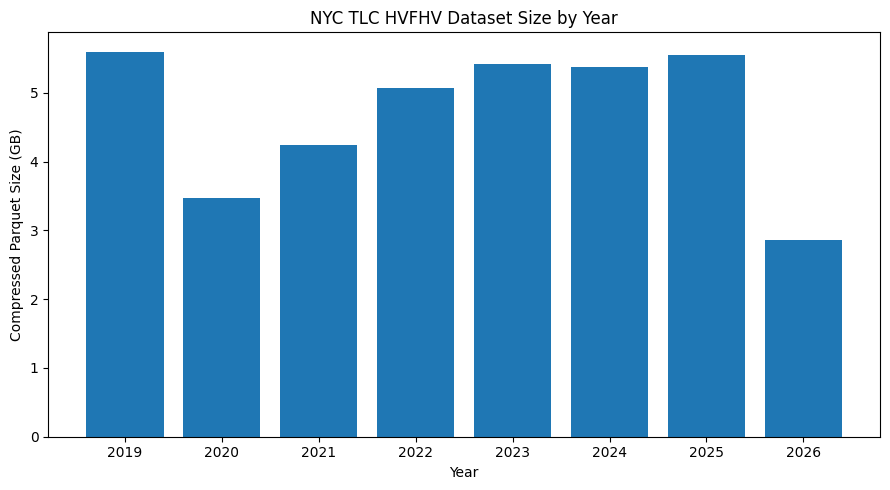

year,files,size_GB
i64,u32,f64
2019,11,5.60
2020,12,3.47
2021,12,4.24
2022,12,5.06
2023,12,5.42
2024,12,5.38
2025,12,5.55
2026,6,2.86


In [107]:
yearly_sizes = (raw_dataset
                .group_by("year")
                .agg(files=pl.len(), size_GB=pl.col("size_GB").sum())
                .sort("year"))

plt.figure(figsize=(9, 5))
plt.bar(yearly_sizes["year"].cast(pl.String), yearly_sizes["size_GB"])
plt.title("NYC TLC HVFHV Dataset Size by Year")
plt.xlabel("Year")
plt.ylabel("Compressed Parquet Size (GB)")
plt.tight_layout()
save_fig("hvfhv_size_by_year")
plt.show()

yearly_sizes


### 2.8 Provenance, licence and subset justification

**Provenance.** The trip records are published by the New York City Taxi & Limousine Commission (NYC TLC) and originate from licensed high-volume for-hire vehicle bases. The TLC notes that the trip records are provided by the bases and that it does not guarantee complete accuracy or completeness.

**Licence / academic suitability.** The records are publicly available through NYC Open Data / NYC TLC for public use. The project references the original source and download locations rather than redistributing the dataset files.

**Subset justification.** The raw project dataset is a continuous set of original TLC monthly Parquet files selected programmatically to satisfy the required 25–40 GB range. The working dataset (≥12 GB) and processing dataset (≥3 GB) are nested subsets of that raw collection. Recent contiguous months are used for temporal coherence and reproducibility; they represent recent HVFHV activity but are not assumed to represent all transport activity in New York City.

**Part 1 versus Part 2.** Part 1 uses one representative monthly file for Polars-based EDA. Part 2 will use the full ≥3 GB processing collection in PySpark for substantive distributed processing.


## 3. Load the representative processing-set month


In [108]:
df = pl.read_parquet(EDA_SAMPLE_URL)

print("Loaded:", EDA_SAMPLE_FILE)
print("Rows:", f"{df.height:,}")
print("Columns:", df.width)
print(f"Estimated in-memory size: {df.estimated_size('gb'):.2f} GB")


Loaded: fhvhv_tripdata_2026-06.parquet
Rows: 20,775,868
Columns: 25
Estimated in-memory size: 2.89 GB


### 3.1 Inspect the schema


In [109]:
df.head()


hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
str,str,str,datetime[μs],datetime[μs],datetime[μs],datetime[μs],i32,i32,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64
"""HV0003""","""B03404""","""B03404""",2026-06-01 00:38:26,2026-06-01 00:42:10,2026-06-01 00:44:10,2026-06-01 00:49:03,86,86,1.26,293,10.57,0.00,0.27,0.94,0.00,0.00,0.00,20.93,"""N""","""N""","""N""","""N""","""N""",0.00
"""HV0003""","""B03404""","""B03404""",2026-06-01 00:54:23,2026-06-01 00:56:26,2026-06-01 00:56:39,2026-06-01 01:01:27,86,86,1.03,288,11.68,0.00,0.29,1.02,0.00,0.00,0.00,6.09,"""N""","""N""","""N""","""N""","""N""",0.00
"""HV0005""","""B03406""",null,2026-06-01 00:04:38,2026-06-01 00:09:04,2026-06-01 00:09:22,2026-06-01 00:33:00,262,49,9.23,1418,36.98,0.00,0.92,3.28,2.75,0.00,0.00,27.94,"""N""","""N""","""N""","""N""","""N""",0.00
"""HV0005""","""B03406""",null,2026-06-01 00:33:19,2026-06-01 00:37:42,2026-06-01 00:37:53,2026-06-01 00:46:07,49,25,1.33,494,10.91,0.00,0.23,0.81,0.00,0.00,2.39,7.32,"""N""","""N""","""N""","""N""","""N""",0.00
"""HV0003""","""B03404""","""B03404""",2026-06-01 00:13:45,2026-06-01 00:17:08,2026-06-01 00:17:58,2026-06-01 01:10:29,140,216,20.75,3151,43.53,7.46,1.14,4.70,0.75,0.00,5.95,47.96,"""Y""","""Y""","""N""","""N""","""N""",0.00


In [110]:
# Polars equivalent of pandas df.info(): dtypes plus a preview per column
df.glimpse()


Rows: 20775868
Columns: 25
$ hvfhs_license_num             <str> 'HV0003', 'HV0003', 'HV0005', 'HV0005', 'HV0003', 'HV0003', 'HV0005', 'HV0003', 'HV0005', 'HV0003'
$ dispatching_base_num          <str> 'B03404', 'B03404', 'B03406', 'B03406', 'B03404', 'B03404', 'B03406', 'B03404', 'B03406', 'B03404'
$ originating_base_num          <str> 'B03404', 'B03404', null, null, 'B03404', 'B03404', null, 'B03404', null, 'B03404'
$ request_datetime     <datetime[μs]> 2026-06-01 00:38:26, 2026-06-01 00:54:23, 2026-06-01 00:04:38, 2026-06-01 00:33:19, 2026-06-01 00:13:45, 2026-06-01 00:23:41, 2026-06-01 00:21:49, 2026-06-01 00:16:46, 2026-05-31 23:54:21, 2026-06-01 00:27:41
$ on_scene_datetime    <datetime[μs]> 2026-06-01 00:42:10, 2026-06-01 00:56:26, 2026-06-01 00:09:04, 2026-06-01 00:37:42, 2026-06-01 00:17:08, 2026-06-01 00:32:28, 2026-06-01 00:30:51, 2026-06-01 00:22:49, 2026-05-31 23:58:46, 2026-06-01 00:31:35
$ pickup_datetime      <datetime[μs]> 2026-06-01 00:44:10, 2026-06-01 00:56:39, 2026

In [111]:
print(df.columns)


['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num', 'request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'cbd_congestion_fee']


### 3.2 Data types (supports the Variety discussion)


In [112]:
dtype_table = pl.DataFrame({
    "Column": df.columns,
    "Data Type": [str(dt) for dt in df.dtypes]
})
dtype_table


Column,Data Type
str,str
"""hvfhs_license_num""","""String"""
"""dispatching_base_num""","""String"""
"""originating_base_num""","""String"""
"""request_datetime""","""Datetime(time_unit='us', time_…"
"""on_scene_datetime""","""Datetime(time_unit='us', time_…"
…,…
"""shared_match_flag""","""String"""
"""access_a_ride_flag""","""String"""
"""wav_request_flag""","""String"""


## 4. Derived fields

HVFHV has no `passenger_count` (a limitation we note later), but it exposes fields yellow taxi does not: a company code, request/on-scene timestamps (enabling wait-time analysis), and driver pay. We derive:

* `company` — readable label from `hvfhs_license_num`
* `trip_duration_minutes` — from pickup/dropoff timestamps
* `wait_time_minutes` — from request to on-scene (rider wait for the car)
* `total_amount` — sum of the fare and surcharge components
* calendar features for temporal EDA


In [113]:
company_map = {"HV0002": "Juno", "HV0003": "Uber", "HV0004": "Via", "HV0005": "Lyft"}

fee_cols = ["base_passenger_fare", "tolls", "bcf", "sales_tax",
            "congestion_surcharge", "airport_fee", "tips"]
if "cbd_congestion_fee" in df.columns:          # present from 2025 onward
    fee_cols.append("cbd_congestion_fee")
present_fees = [c for c in fee_cols if c in df.columns]
print("Fee components used for total_amount:", present_fees)

df = df.with_columns(
    # replace() keeps unmapped licence codes as-is (pandas map + fillna equivalent)
    pl.col("hvfhs_license_num").replace(company_map).alias("company"),
    ((pl.col("dropoff_datetime") - pl.col("pickup_datetime"))
        .dt.total_seconds() / 60).alias("trip_duration_minutes"),
    # on_scene_datetime is not populated by every base (notably Lyft),
    # so wait_time stays null for those rows - handled in the quality section.
    ((pl.col("on_scene_datetime") - pl.col("request_datetime"))
        .dt.total_seconds() / 60).alias("wait_time_minutes"),
    pl.sum_horizontal(present_fees).alias("total_amount"),
    pl.col("pickup_datetime").dt.hour().alias("pickup_hour"),
    pl.col("pickup_datetime").dt.strftime("%A").alias("pickup_day"),
    pl.col("pickup_datetime").dt.date().alias("pickup_date"),
    pl.col("pickup_datetime").dt.month().alias("pickup_month"),
)

df.select(["company", "trip_miles", "trip_duration_minutes",
           "wait_time_minutes", "base_passenger_fare", "total_amount"]).head()


Fee components used for total_amount: ['base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'cbd_congestion_fee']


company,trip_miles,trip_duration_minutes,wait_time_minutes,base_passenger_fare,total_amount
str,f64,f64,f64,f64,f64
"""Uber""",1.26,4.88,3.73,10.57,11.78
"""Uber""",1.03,4.80,2.05,11.68,12.99
"""Lyft""",9.23,23.63,4.43,36.98,43.93
"""Lyft""",1.33,8.23,4.38,10.91,14.34
"""Uber""",20.75,52.52,3.38,43.53,63.53


## 5. Data-quality assessment


### 5.1 Missing values


In [114]:
missing_df = (pl.DataFrame({
    "Column": df.columns,
    "Missing Values": df.null_count().row(0)
}).with_columns(
    (pl.col("Missing Values") / df.height * 100).alias("Missing Percentage")
).sort("Missing Percentage", descending=True))

missing_df.write_csv(os.path.join(OUT_DIR, "missing_values_raw.csv"))
missing_df


Column,Missing Values,Missing Percentage
str,i64,f64
"""originating_base_num""",5495740,26.45
"""hvfhs_license_num""",0,0.00
"""dispatching_base_num""",0,0.00
"""request_datetime""",0,0.00
"""on_scene_datetime""",0,0.00
…,…,…
"""total_amount""",0,0.00
"""pickup_hour""",0,0.00
"""pickup_day""",0,0.00


### 5.2 Missingness is structural, not random

`on_scene_datetime` (and therefore `wait_time_minutes`) is missing in a company-specific pattern rather than at random — some bases do not report the on-scene time. Showing missingness **by company** turns a generic "X% missing" observation into a veracity finding with a mechanism.


In [115]:
onscene_missing = (df.group_by("company")
                   .agg((pl.col("on_scene_datetime").is_null().mean() * 100)
                        .alias("on_scene_missing_%"))
                   .sort("on_scene_missing_%", descending=True))
onscene_missing


company,on_scene_missing_%
str,f64
"""Uber""",0.00
"""Lyft""",0.00


### 5.3 Duplicate rows


In [ ]:
# is_duplicated marks every occurrence, unlike pandas .duplicated() which skips the first
duplicate_count = int(df.is_duplicated().sum())
print(f"Rows that are part of a duplicate group: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / df.height * 100:.4f}%")


### 5.4 Descriptive statistics


In [ ]:
df.describe()


### 5.5 Trip-duration anomalies


In [ ]:
print("Duration <= 0 min:", int((df["trip_duration_minutes"] <= 0).sum()))
print("Duration > 24 h:  ", int((df["trip_duration_minutes"] > 1440).sum()))
df["trip_duration_minutes"].describe()


### 5.6 Trip-distance anomalies (`trip_miles`)


In [ ]:
print("Negative distance:", int((df["trip_miles"] < 0).sum()))
print("Zero distance:    ", int((df["trip_miles"] == 0).sum()))
print("Over 100 miles:   ", int((df["trip_miles"] > 100).sum()))
df["trip_miles"].describe()


### 5.7 Fare anomalies (`base_passenger_fare`)


In [ ]:
print("Negative fares:", int((df["base_passenger_fare"] < 0).sum()))
print("Zero fares:    ", int((df["base_passenger_fare"] == 0).sum()))
print("Fares > $500:  ", int((df["base_passenger_fare"] > 500).sum()))
df["base_passenger_fare"].describe()


### 5.8 Wait-time sanity check

Negative waits (on-scene before request) indicate clock/entry errors; extreme waits are implausible. We only report these here — we do **not** drop rows on wait time, because its missingness is structural (see 5.2) and unrelated to the validity of the trip itself.


In [ ]:
print("Non-missing wait times:", int(df["wait_time_minutes"].is_not_null().sum()))
print("Negative wait times:   ", int((df["wait_time_minutes"] < 0).sum()))
print("Wait > 60 min:         ", int((df["wait_time_minutes"] > 60).sum()))
df["wait_time_minutes"].describe()


### 5.9 Note on `passenger_count`

Unlike yellow-taxi data, HVFHV records contain **no passenger count**, so occupancy-based analysis is not possible on this dataset. This is carried forward as a stated limitation in the report.


## 6. Data preparation and cleaning

The raw sample is preserved unchanged for the quality assessment above. A separate analytical copy (`df_clean`) is created so implausible observations can be excluded without altering the original. The filters below are **analytical plausibility rules**, not claims that every excluded row is erroneous.


### 6.1 Preserve raw, create clean copy


In [ ]:
# Polars frames are immutable, so no defensive .copy() is needed:
# filtering below produces a new frame and leaves the raw df untouched.
df_clean = df
raw_rows = df_clean.height
print(f"Raw number of records: {raw_rows:,}")


### 6.2 Inspect extremes before filtering


In [ ]:
qs = [0.0, 0.01, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999, 1.0]

pl.DataFrame({"quantile": qs,
              "trip_miles": [df_clean["trip_miles"].quantile(q) for q in qs]})

In [ ]:
pl.DataFrame({"quantile": qs,
              "trip_duration_minutes": [df_clean["trip_duration_minutes"].quantile(q) for q in qs]})


In [ ]:
pl.DataFrame({"quantile": qs,
              "base_passenger_fare": [df_clean["base_passenger_fare"].quantile(q) for q in qs]})


### 6.3 Define plausibility filters

* duration in (0, 1440] minutes
* distance in (0, 100] miles
* base passenger fare in [0, 500] dollars


In [ ]:
# Filters are Polars expressions, evaluated lazily inside filter()
valid_duration = (pl.col("trip_duration_minutes") > 0) & (pl.col("trip_duration_minutes") <= 1440)
valid_distance = (pl.col("trip_miles") > 0) & (pl.col("trip_miles") <= 100)
valid_fare     = (pl.col("base_passenger_fare") >= 0) & (pl.col("base_passenger_fare") <= 500)

print(f"Invalid duration records: {df_clean.filter(~valid_duration).height:,}")
print(f"Invalid distance records: {df_clean.filter(~valid_distance).height:,}")
print(f"Invalid fare records:     {df_clean.filter(~valid_fare).height:,}")


### 6.4 Apply combined cleaning


In [ ]:
df_clean = df_clean.filter(valid_duration & valid_distance & valid_fare)

clean_rows = df_clean.height
removed_rows = raw_rows - clean_rows
removed_percentage = removed_rows / raw_rows * 100

print(f"Raw records:        {raw_rows:,}")
print(f"Clean records:      {clean_rows:,}")
print(f"Records excluded:   {removed_rows:,}")
print(f"Percentage excluded: {removed_percentage:.2f}%")


### 6.5 Verify cleaning worked


In [ ]:
checks = {
    "Non-positive durations": (df_clean["trip_duration_minutes"] <= 0).sum(),
    "Durations > 24 h":       (df_clean["trip_duration_minutes"] > 1440).sum(),
    "Non-positive distances": (df_clean["trip_miles"] <= 0).sum(),
    "Distances > 100 miles":  (df_clean["trip_miles"] > 100).sum(),
    "Negative fares":         (df_clean["base_passenger_fare"] < 0).sum(),
    "Fares > $500":           (df_clean["base_passenger_fare"] > 500).sum(),
}
for k, v in checks.items():
    print(f"{k:<24}: {int(v)}")


### 6.6 Before/after cleaning table


In [ ]:
cleaning_summary = pl.DataFrame({
    "Metric": ["Number of records", "Zero-distance trips",
               "Negative-fare trips", "Non-positive-duration trips"],
    "Raw Data": [df.height,
                 int((df["trip_miles"] == 0).sum()),
                 int((df["base_passenger_fare"] < 0).sum()),
                 int((df["trip_duration_minutes"] <= 0).sum())],
    "Clean Data": [df_clean.height,
                   int((df_clean["trip_miles"] == 0).sum()),
                   int((df_clean["base_passenger_fare"] < 0).sum()),
                   int((df_clean["trip_duration_minutes"] <= 0).sum())]
})
cleaning_summary.write_csv(os.path.join(OUT_DIR, "cleaning_summary.csv"))
cleaning_summary


## 7. Exploratory Data Analysis


### 7.1 How extreme values distort the distance-fare relationship

We compute the correlation between trip distance and fare **before and after** removing implausible extremes. Extreme GPS/entry errors can mask an otherwise strong relationship; comparing the two figures shows why preparation matters rather than merely asserting it. (Report whatever your run produces — do not assume a fixed number.)


In [ ]:
raw_corr = df.select(pl.corr("trip_miles", "base_passenger_fare")).item()
clean_corr = df_clean.select(pl.corr("trip_miles", "base_passenger_fare")).item()
print(f"Raw distance-fare correlation:   {raw_corr:.4f}")
print(f"Clean distance-fare correlation: {clean_corr:.4f}")


In [ ]:
plot_sample = (df_clean.select(["trip_miles", "base_passenger_fare"])
               .drop_nulls()
               .sample(n=min(50000, df_clean.height), seed=42))

plt.figure(figsize=(8, 6))
plt.scatter(plot_sample["trip_miles"], plot_sample["base_passenger_fare"],
            alpha=0.2, s=5)
plt.xlim(0, 30)
plt.ylim(0, 150)
plt.title("Trip Distance vs Base Passenger Fare - Cleaned Data")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Base Passenger Fare ($)")
plt.tight_layout()
save_fig("distance_vs_fare_clean")
plt.show()


### 7.2 Trips by hour of day


In [ ]:
trips_by_hour = df_clean.group_by("pickup_hour").len().sort("pickup_hour")

plt.figure(figsize=(10, 5))
plt.bar(trips_by_hour["pickup_hour"], trips_by_hour["len"])
plt.title("HVFHV Trips by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.tight_layout()
save_fig("trips_by_hour")
plt.show()


### 7.3 Trips by day of week


In [ ]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Join against the ordered day list to fix weekday order (pandas reindex equivalent)
trips_by_day = (pl.DataFrame({"pickup_day": day_order})
                .join(df_clean.group_by("pickup_day").len(), on="pickup_day", how="left"))

plt.figure(figsize=(10, 5))
plt.bar(trips_by_day["pickup_day"], trips_by_day["len"])
plt.title("HVFHV Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig("trips_by_day")
plt.show()


### 7.4 Average trip characteristics by hour


In [ ]:
hourly = (df_clean.group_by("pickup_hour").agg(
    avg_distance=pl.col("trip_miles").mean(),
    avg_fare=pl.col("base_passenger_fare").mean(),
    avg_duration=pl.col("trip_duration_minutes").mean())
    .sort("pickup_hour"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
panels = [("avg_distance", "Avg Distance (miles) by Hour"),
          ("avg_fare", "Avg Fare ($) by Hour"),
          ("avg_duration", "Avg Duration (min) by Hour")]
for ax, (col, title) in zip(axes, panels):
    ax.plot(hourly["pickup_hour"], hourly[col], marker="o")
    ax.set_title(title)
    ax.set_xlabel("Hour of Day")
    ax.grid(alpha=0.3)
plt.tight_layout()
save_fig("hourly_characteristics")
plt.show()

hourly


### 7.5 Weekday behaviour summary


In [ ]:
weekday_summary = (pl.DataFrame({"pickup_day": day_order})
                   .join(df_clean.group_by("pickup_day").agg(
                       trips=pl.len(),
                       avg_distance=pl.col("trip_miles").mean(),
                       avg_duration=pl.col("trip_duration_minutes").mean(),
                       avg_fare=pl.col("base_passenger_fare").mean()),
                       on="pickup_day", how="left"))
weekday_summary.write_csv(os.path.join(OUT_DIR, "weekday_summary.csv"))
weekday_summary


### 7.6 Company breakdown

`hvfhs_license_num` allows the monthly data to be grouped by reported high-volume base/company. The analysis below measures the observed trip share and average trip/fare characteristics for the companies actually present in the selected EDA month.

Company shares are calculated from the selected EDA month.


In [ ]:
company_summary = (df_clean.group_by("company").agg(
    trips=pl.len(),
    avg_miles=pl.col("trip_miles").mean(),
    avg_fare=pl.col("base_passenger_fare").mean(),
    avg_driver_pay=pl.col("driver_pay").mean(),
    avg_tips=pl.col("tips").mean())
    .sort("trips", descending=True)
    .with_columns((100 * pl.col("trips") / pl.col("trips").sum())
                  .alias("market_share_%")))
company_summary.write_csv(os.path.join(OUT_DIR, "company_summary.csv"))
company_summary


In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(company_summary["company"], company_summary["trips"])
plt.title("HVFHV Trips by Company")
plt.xlabel("Company")
plt.ylabel("Number of Trips")
plt.tight_layout()
save_fig("trips_by_company")
plt.show()


### 7.7 Driver pay relative to base passenger fare

This metric compares `driver_pay` with `base_passenger_fare` for trips where the base passenger fare is positive.

It should **not** be interpreted as the driver's share of the rider's complete payment, because the trip record can also include tolls, taxes, surcharges, congestion fees, airport fees and tips. It is therefore labelled **driver pay relative to base passenger fare**, not a general driver "take-rate".


In [ ]:
driver_pay_ratio_by_company = (
    df_clean
    .filter(pl.col("base_passenger_fare") > 0)
    .with_columns((pl.col("driver_pay") / pl.col("base_passenger_fare"))
                  .alias("driver_pay_to_base_fare_ratio"))
    .filter(pl.col("driver_pay_to_base_fare_ratio").is_between(0, 2))
    .group_by("company")
    .agg((pl.col("driver_pay_to_base_fare_ratio").mean() * 100)
         .alias("avg_driver_pay_as_%_of_base_fare"))
    .sort("avg_driver_pay_as_%_of_base_fare", descending=True)
)
driver_pay_ratio_by_company


### 7.8 Rider wait time by hour (request → on-scene)

Wait time is available only where `on_scene_datetime` is reported (see 5.2), so this view is effectively driven by the reporting operators. We bound to plausible waits (0-60 min).


In [ ]:
wait_by_hour = (df_clean
                .filter(pl.col("wait_time_minutes").is_between(0, 60))
                .group_by("pickup_hour")
                .agg(avg_wait=pl.col("wait_time_minutes").mean())
                .sort("pickup_hour"))

plt.figure(figsize=(10, 5))
plt.plot(wait_by_hour["pickup_hour"], wait_by_hour["avg_wait"], marker="o")
plt.title("Average Rider Wait Time by Pickup Hour (request to on-scene)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Wait (minutes)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
save_fig("wait_time_by_hour")
plt.show()


### 7.9 Spatial view: join the TLC taxi-zone lookup


In [ ]:
zone_lookup_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zones = pl.read_csv(zone_lookup_url)
print(zones.shape)
display(zones.head())

In [ ]:
# Cast the join key so it matches the trip data's integer width exactly
pickup_zones = (zones
                .rename({"LocationID": "PULocationID", "Borough": "PU_Borough", "Zone": "PU_Zone"})
                .with_columns(pl.col("PULocationID").cast(df_clean.schema["PULocationID"])))

df_clean = df_clean.join(
    pickup_zones.select(["PULocationID", "PU_Borough", "PU_Zone"]),
    on="PULocationID", how="left")

display(df_clean.select(["PULocationID", "PU_Borough", "PU_Zone"]).head())

### 7.10 Top pickup zones


In [ ]:
top_zones = (df_clean["PU_Zone"].value_counts()
             .sort("count", descending=True)
             .head(15))

plot_zones = top_zones.reverse()          # smallest at the bottom of the barh chart
plt.figure(figsize=(10, 7))
plt.barh(plot_zones["PU_Zone"], plot_zones["count"])
plt.title("Top 15 HVFHV Pickup Zones")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Zone")
plt.tight_layout()
save_fig("top_pickup_zones")
plt.show()

display(top_zones)

### 7.11 Pickups by borough

The borough distribution is examined to assess the geographic concentration of HVFHV pickup activity in the selected EDA month.

The borough distribution is used to assess the geographic concentration of pickup activity in the selected EDA month.


In [ ]:
borough_trips = (df_clean["PU_Borough"].value_counts()
                 .sort("count", descending=True))

plt.figure(figsize=(8, 5))
plt.bar(borough_trips["PU_Borough"], borough_trips["count"])
plt.title("HVFHV Pickups by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig("pickups_by_borough")
plt.show()

display(borough_trips)

### 7.12 Origin-destination (OD) flow matrix

The dropoff zones are joined so trips can be viewed as origin→destination flows. The full $265{\times}265$ zone-level matrix is rendered as a log-scaled heatmap (raw counts span several orders of magnitude), and a borough-level OD summary table is saved for the report.

In [ ]:
# Zone-level OD counts filled into a dense 265x265 numpy matrix
od_counts = df_clean.group_by(["PULocationID", "DOLocationID"]).len()

n_zones = int(zones["LocationID"].max())
od_matrix = np.zeros((n_zones, n_zones), dtype=np.int64)
# Ensure indices are within range for the matrix
pickup_indices = od_counts["PULocationID"].to_numpy().astype(int) - 1
dropoff_indices = od_counts["DOLocationID"].to_numpy().astype(int) - 1
valid_mask = (pickup_indices < n_zones) & (dropoff_indices < n_zones)
od_matrix[pickup_indices[valid_mask], dropoff_indices[valid_mask]] = od_counts["len"].to_numpy()[valid_mask]

plt.figure(figsize=(9, 8))
plt.imshow(np.log1p(od_matrix), cmap="viridis", aspect="equal")
plt.colorbar(label="log(1 + trips)")
plt.title("HVFHV Origin-Destination Flow Matrix (265 x 265 zones)")
plt.xlabel("Dropoff LocationID")
plt.ylabel("Pickup LocationID")
plt.tight_layout()
save_fig("od_flow_matrix")
plt.show()

# Borough-level OD summary
do_zones = (zones
            .rename({"LocationID": "DOLocationID", "Borough": "DO_Borough", "Zone": "DO_Zone"})
            .with_columns(pl.col("DOLocationID").cast(df_clean.schema["DOLocationID"])))
df_clean = df_clean.join(
    do_zones.select(["DOLocationID", "DO_Borough", "DO_Zone"]),
    on="DOLocationID", how="left")

borough_od = (df_clean.group_by(["PU_Borough", "DO_Borough"]).len()
              .pivot(on="DO_Borough", index="PU_Borough", values="len")
              .fill_null(0)
              .sort("PU_Borough"))
borough_od.write_csv(os.path.join(OUT_DIR, "borough_od_matrix.csv"))
display(borough_od)

### 7.13 Airport pickups

HVFHV pickups at the three airport zones are compared directly. Newark is included where present but lies outside the five boroughs, so LaGuardia and JFK are the primary comparison.

In [ ]:
airport_zones = ["LaGuardia Airport", "JFK Airport", "Newark Airport"]
airport_pickups = (df_clean.filter(pl.col("PU_Zone").is_in(airport_zones))["PU_Zone"]
                   .value_counts()
                   .sort("count", descending=True))

plt.figure(figsize=(7, 5))
plt.bar(airport_pickups["PU_Zone"], airport_pickups["count"])
plt.title("HVFHV Airport Pickups")
plt.xlabel("Airport Zone")
plt.ylabel("Number of Pickups")
plt.tight_layout()
save_fig("airport_pickups")
plt.show()

display(airport_pickups)

### 7.14 Distribution spread: box-and-whisker views

 Section 6.2. Box-and-whisker plots add the median, interquartile range and skew, so differences between groups can be attributed to typical trips rather than tails. Three comparisons are shown:

* **Trip distance by company** — complements the 7.6 company means; shows whether operators serve genuinely different trip profiles.
* **Base fare by day of week** — complements the 7.5 weekday means; shows whether the weekend effect moves the whole distribution or only the tail.
* **Wait time by pickup hour** — complements the 7.8 hourly mean line; shows the spread of waits riders actually experience at each hour.

A fixed random sample is used (boxplots draw from individual observations, and the full month is unnecessarily large for this), and outlier fliers are hidden because the plausibility filters in 6.3 are deliberately wide — the boxes and whiskers carry the comparison.


In [ ]:
# Fixed-seed sample: boxplots draw from individual observations, full month is too large
box_sample = df_clean.sample(n=min(200_000, df_clean.height), seed=42)

companies = (box_sample["company"].value_counts()
             .sort("count", descending=True)["company"].to_list())
company_groups = [box_sample.filter(pl.col("company") == c)["trip_miles"].to_numpy()
                  for c in companies]

plt.figure(figsize=(9, 5))
plt.boxplot(company_groups, labels=companies, showfliers=False)
plt.title("Trip Distance by Company (outliers hidden)")
plt.xlabel("Company")
plt.ylabel("Trip Distance (miles)")
plt.tight_layout()
save_fig("box_distance_by_company")
plt.show()


In [ ]:
day_groups = [box_sample.filter(pl.col("pickup_day") == d)["base_passenger_fare"].to_numpy()
              for d in day_order]

plt.figure(figsize=(11, 5))
plt.boxplot(day_groups, labels=day_order, showfliers=False)
plt.title("Base Passenger Fare by Day of Week (outliers hidden)")
plt.xlabel("Day of Week")
plt.ylabel("Base Passenger Fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig("box_fare_by_day")
plt.show()


In [ ]:
# Same plausible-wait bound as 7.8 (0-60 min); missing waits drop out automatically
wait_box = box_sample.filter(pl.col("wait_time_minutes").is_between(0, 60))

hours = sorted(wait_box["pickup_hour"].unique().to_list())
hour_groups = [wait_box.filter(pl.col("pickup_hour") == h)["wait_time_minutes"].to_numpy()
               for h in hours]

plt.figure(figsize=(13, 5))
plt.boxplot(hour_groups, labels=hours, showfliers=False)
plt.title("Rider Wait Time by Pickup Hour (outliers hidden)")
plt.xlabel("Hour of Day")
plt.ylabel("Wait Time (minutes)")
plt.tight_layout()
save_fig("box_wait_by_hour")
plt.show()


eda_summary = pl.DataFrame({
    "Metric": ["Raw records (sample month)", "Clean records", "Records excluded (%)",
               "Mean trip distance (miles)", "Median trip distance (miles)",
               "Mean trip duration (minutes)", "Median trip duration (minutes)",
               "Mean base fare ($)", "Median base fare ($)",
               "Raw distance-fare correlation", "Clean distance-fare correlation"],
    "Value": [float(raw_rows), float(clean_rows), round(removed_percentage, 2),
              round(df_clean["trip_miles"].mean(), 2),
              round(df_clean["trip_miles"].median(), 2),
              round(df_clean["trip_duration_minutes"].mean(), 2),
              round(df_clean["trip_duration_minutes"].median(), 2),
              round(df_clean["base_passenger_fare"].mean(), 2),
              round(df_clean["base_passenger_fare"].median(), 2),
              round(raw_corr, 4), round(clean_corr, 4)]
})
eda_summary.write_csv(os.path.join(OUT_DIR, "eda_summary.csv"))
display(eda_summary)

In [ ]:
eda_summary = pl.DataFrame({
    "Metric": ["Raw records (sample month)", "Clean records", "Records excluded (%)",
               "Mean trip distance (miles)", "Median trip distance (miles)",
               "Mean trip duration (minutes)", "Median trip duration (minutes)",
               "Mean base fare ($)", "Median base fare ($)",
               "Raw distance-fare correlation", "Clean distance-fare correlation"],
    "Value": [float(raw_rows), float(clean_rows), round(removed_percentage, 2),
              round(df_clean["trip_miles"].mean(), 2),
              round(df_clean["trip_miles"].median(), 2),
              round(df_clean["trip_duration_minutes"].mean(), 2),
              round(df_clean["trip_duration_minutes"].median(), 2),
              round(df_clean["base_passenger_fare"].mean(), 2),
              round(df_clean["base_passenger_fare"].median(), 2),
              round(raw_corr, 4), round(clean_corr, 4)]
})
eda_summary.write_csv(os.path.join(OUT_DIR, "eda_summary.csv"))
eda_summary


### 8.1 Report summary

Report the verified results from the executed notebook:

* **Scale:** report the verified raw, working and processing sizes from Section 2 and confirm that each requirement is met.
* **EDA sample distinction:** state clearly that Part 1 Polars EDA uses one monthly file, while the ≥3 GB processing collection is reserved for PySpark in Part 2.
* **Data quality:** report observed missingness, duplicates and implausible distance/duration/fare values; explain the transparent plausibility filters used.
* **Relationships and patterns:** report only patterns actually observed in the run, such as distance–fare association, hourly/weekday demand, company shares, wait-time patterns and borough/zone concentration.
* **Driver-pay metric:** describe it as driver pay relative to base passenger fare, not as the driver's share of the rider's total payment.
* **Representativeness:** treat HVFHV as one segment of NYC mobility and avoid generalising its patterns to all transport modes.
* **Reproducibility:** figures are saved to `figures/` and tables to `output/`. Run the notebook top-to-bottom before submission so all saved outputs match the report.
